# MSC Marc decks and post files, and Ansys element results

Added in v16.8.0:

- **MSC Marc input decks (`.dat`)** are what Marc Mentat writes and the Marc solver reads: fixed-column or free-format cards, with `COORDINATES`, `CONNECTIVITY` and `DEFINE` sets in the model definition.
- **Marc formatted post files (`.t19`)** are the ASCII twin of Marc's binary `.t16` results: the model, then one group of blocks per increment.
- **Ansys `.rst` element results.** The MAPDL results reader of v16.3.0 read the nodal solution; it now also reads reaction forces and the element nodal stresses, strains and forces, merges the files of a distributed solve, and expands a static cyclic-symmetry model to its full rotor.

The Marc files are in `tests/python/meshes/marc/`, written from the Marc manuals (no permissively licensed Marc file exists); the Ansys files are MAPDL output from pymapdl-reader (MIT).

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def curved(grid, level=3):
    '''The surface of `grid` with its quadratic cells subdivided, so curved edges look curved.'''
    return grid.extract_surface(nonlinear_subdivision=level, algorithm='dataset_surface')


def to_grid(mesh, cell_data=None, point_data=None):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4')]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460), view=(-1.0, -1.4, 0.45), edges=True, zoom=1.0):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=edges, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector(view, viewup=(0, 1, 0) if view == (0, 0, 1) else (0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(zoom)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def von_mises(t):
    """The von Mises stress of tensors ``xx yy zz xy yz zx`` (the last axis)."""
    xx, yy, zz, xy, yz, zx = np.moveaxis(t, -1, 0)
    return np.sqrt(0.5 * ((xx - yy) ** 2 + (yy - zz) ** 2 + (zz - xx) ** 2) + 3 * (xy**2 + yz**2 + zx**2))

## A Marc deck

`.dat` is also Tecplot's extension. A `.dat` file that opens with a Marc parameter (`title`, `sizing`, `extended` ...) and reaches `END` or `CONNECTIVITY` is read as a Marc deck; anything else is still Tecplot's. `hex20.dat` holds two 20-node bricks (Marc type 21) in fixed 5/10-column fields; Marc lists their nodes in meshio++'s order already. The element and node sets are ranges (`100 to 200 by 100`), other sets' names and `EXCEPT` and `AND` combinations.

<meshio++ mesh object>
  Number of points: 32
  Number of cells:
    hexahedron20: 2
  Point sets: top_face, top_not_x0, x0_face
  Cell sets: both, both_again, left, right
  Cell data: marc:element, marc:type
title               two hex20 bricks
$....a fixture written by tools/gen_marc_fixtures.py
sizing                  0    2   32    0
elements               21
end
$...................
connectivity
    2    0    1
  100   21   10   30  130  110  310  330  430  410   20   80  120   60  320  380
  420  360  160  180  280  260
  200   21   30   50  150  130  330  350  450  430   40  100  140   80  340  400
  440  380  180  200  300  280

top_face    point [2, 3, 7, 8, 11, 12, 13, 17, 18, 22, 23, 27, 31]
top_not_x0  point [2, 3, 7, 8, 12, 13, 18, 22, 27, 31]
x0_face     point [6, 11, 14, 17, 19, 23, 25, 29]
both        cell  [0, 1]
both_again  cell  [0, 1]
left        cell  [0]
right       cell  [1]


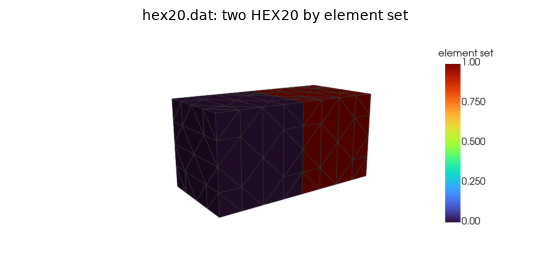

In [2]:
deck = mp.read(path('marc', 'hex20.dat'))
print(deck)
with open(path('marc', 'hex20.dat')) as fh:
    print(''.join(fh.readlines()[:12]))
for r in deck.regions:
    print(f'{r.name:11s} {r.kind:5s} {r.entries.tolist()}')
gallery([(curved(to_grid(deck, cell_data={'element set': region_array(deck, ['left', 'right'])}), 2),
          'element set', 'hex20.dat: two HEX20 by element set', None)], ncols=1, size=(1000, 420))

With `EXTENDED` every field is twice as wide, and Marc Mentat writes reals with an exponent but no `E`: `5.000000000000000-1` is 0.5, and a negative value fills its field so that it touches the node number before it. `hex20_extended.dat` is the same model in that layout; it reads to the same mesh. `mixed_free.dat` uses the free (comma) format: its second brick repeats two nodes, which makes it a wedge, and an element of a type meshio++ has no cell for is skipped with a warning.

fixed == extended: True
         3        32         0         1
       140-9.000000000000000+0-9.000000000000000+0-9.000000000000000+0
       140 1.500000000000000+0 1.000000000000000+0 0.000000000000000+0

[('hexahedron', 1), ('wedge', 1), ('tetra10', 1), ('quad', 1), ('line', 1)] Marc types [[7], [7], [127], [75], [52]]


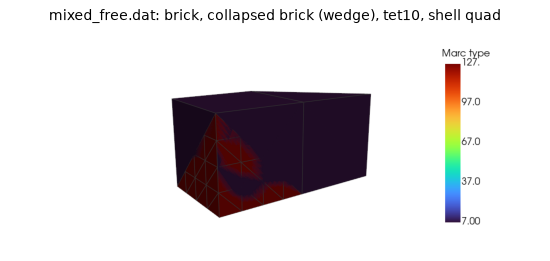

In [3]:
extended = mp.read(path('marc', 'hex20_extended.dat'))
print('fixed == extended:', np.array_equal(deck.points, extended.points)
      and np.array_equal(deck.cells[0].data, extended.cells[0].data))
with open(path('marc', 'hex20_extended.dat')) as fh:
    print(''.join(fh.readlines()[14:17]))
mixed = mp.read(path('marc', 'mixed_free.dat'))
print([(c.type, len(c.data)) for c in mixed.cells], 'Marc types', [t.tolist() for t in mixed.cell_data['marc:type']])
gallery([(curved(to_grid(mixed, cell_data={'Marc type': mixed.cell_data['marc:type']}), 2), 'Marc type',
          'mixed_free.dat: brick, collapsed brick (wedge), tet10, shell quad', None)], ncols=1, size=(1000, 420))

## A Marc post file

`results.t19` holds two 8-node bricks and two increments. Each increment is a step with its time; nodal vectors (`Displacement`, `Reaction Force`) are point data named as the file names them, and element post codes are cell data per integration point. The stress tensor is written as six post codes, 311 to 316; they are combined into one `xx yy zz xy yz zx` array, whose von Mises stress equals the file's own code 17.

increment times: [0.5, 1.0]
<meshio++ mesh object>
  Number of points: 12
  Number of cells:
    hexahedron: 2
  Point sets: fixed, loaded
  Cell sets: second
  Point data: Displacement, Reaction Force
  Cell data: Equivalent Von Mises Stress, Stress, marc:element, marc:type
  Field data: marc:increment, marc:subincrement, meshio:time
stress (2, 8, 6) (cells, integration points, 6)
max |von Mises(tensor) - code 17|: 4.7815371498671766e-05


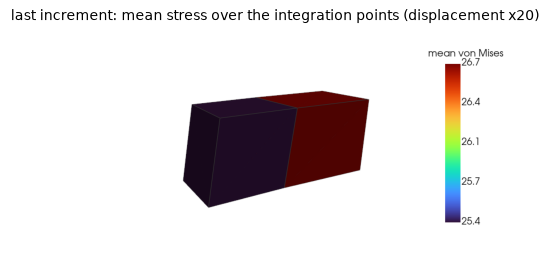

time 0.5: max |U| = 0.0134
time 1.0: max |U| = 0.0247


In [4]:
t19 = path('marc', 'results.t19')
print('increment times:', mp.marc.time_values(t19))
last = mp.read(t19, time_step=-1)
print(last)
stress = last.cell_data['Stress'][0]
print('stress', stress.shape, '(cells, integration points, 6)')
print('max |von Mises(tensor) - code 17|:',
      np.abs(von_mises(stress) - last.cell_data['Equivalent Von Mises Stress'][0]).max())
grid = to_grid(last, point_data={'Displacement': last.point_data['Displacement']},
               cell_data={'mean von Mises': [von_mises(stress).mean(axis=1)]})
gallery([(grid.warp_by_vector('Displacement', factor=20.0), 'mean von Mises',
          'last increment: mean stress over the integration points (displacement x20)', None)],
        ncols=1, size=(1000, 420))
for time, step in mp.read_sequence(t19):
    print(f'time {time}: max |U| = {np.linalg.norm(step.point_data["Displacement"], axis=1).max():.4f}')

## Ansys element results

`beam_static_bc.rst` is a static SOLID186 beam: clamped at one end, loaded at three nodes. Each result set now gives, besides `U`:

- `S` and `EPEL`, the element nodal stresses and elastic strains: per element node as cell data (NaN at the midside nodes, which carry none) and averaged at the corner nodes as point data, as pymapdl-reader's `nodal_stress` does;
- `ENF`, each element's nodal forces, and `RF`, the reaction forces, rotated to the global axes like `U`.

['EPEL', 'EPTH', 'RF', 'S', 'U'] ['ENF', 'EPEL', 'EPTH', 'S']
S per element node: (40, 20, 6)
averaged at the nodes: corners 99 | midside (NaN) 222


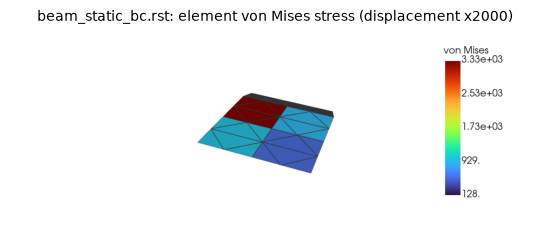

In [5]:
beam = mp.read(path('ansys/rst', 'beam_static_bc.rst'))
print(sorted(beam.point_data), sorted(k for k in beam.cell_data if not k.startswith('ansys:')))
print('S per element node:', beam.cell_data['S'][0].shape)
print('averaged at the nodes: corners', int(np.isfinite(beam.point_data['S'][:, 0]).sum()),
      '| midside (NaN)', int(np.isnan(beam.point_data['S'][:, 0]).sum()))
# Each element's mean von Mises stress over its corner nodes, for the picture.
element_vm = np.nanmean(von_mises(beam.cell_data['S'][0]), axis=1)
grid = to_grid(beam, point_data={'U': beam.point_data['U']}, cell_data={'von Mises': [element_vm]})
gallery([(grid.warp_by_vector('U', factor=2000.0), 'von Mises',
          'beam_static_bc.rst: element von Mises stress (displacement x2000)', None)],
        ncols=1, size=(1000, 360), view=(0.3, -1.0, 0.6))

The element nodal forces are in equilibrium: summed at each node over the elements that share it, they give minus the reaction at the supports, minus the applied load at the three loaded nodes, and zero everywhere else.

In [6]:
total = np.zeros((len(beam.points), 3))
np.add.at(total, beam.cells[0].data.ravel(), beam.cell_data['ENF'][0].reshape(-1, 3))
residual = total + np.nan_to_num(beam.point_data['RF'])
loaded = np.abs(residual).max(axis=1) > 1e-6 * np.abs(np.nan_to_num(beam.point_data['RF'])).max()
print('nodes with a reaction:', int(np.isfinite(beam.point_data['RF'][:, 0]).sum()))
print('residual at the loaded nodes:\n', residual[loaded].round(4))

nodes with a reaction: 4
residual at the loaded nodes:
 [[-20.  -0.   0.]
 [ -0. -30.   0.]
 [  0.   0. -40.]]


## A distributed solve

A distributed MAPDL run can leave one results file per process. Reading the main one, `file0.rst`, reads `file1.rst` to `file3.rst` beside it: the models are merged by node number, each element keeps the results of the file that holds it, and reactions at shared nodes are summed. MAPDL's own combined file, `file.rst`, gives the same model and results.

1309 points, 400 cells (merged)
1309 points, 400 cells (combined)
U: max |merged - combined| = 0.00e+00
S: max |merged - combined| = 0.00e+00
RF: max |merged - combined| = 0.00e+00


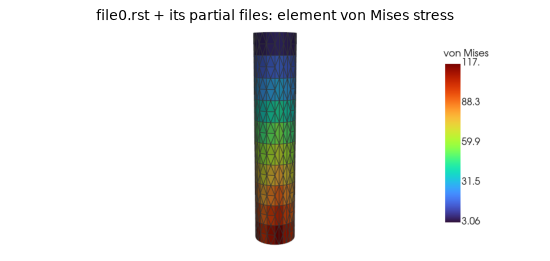

In [7]:
merged = mp.read(path('ansys/rst/dist_static', 'file0.rst'))
combined = mp.read(path('ansys/rst/dist_static', 'file.rst'))
print(len(merged.points), 'points,', sum(len(c.data) for c in merged.cells), 'cells (merged)')
print(len(combined.points), 'points,', sum(len(c.data) for c in combined.cells), 'cells (combined)')
order_m = np.lexsort(merged.points.T)
order_c = np.lexsort(combined.points.T)
for name in ('U', 'S', 'RF'):
    a, b = merged.point_data[name][order_m], combined.point_data[name][order_c]
    print(f'{name}: max |merged - combined| = {np.nanmax(np.abs(a - b)):.2e}')
# The bricks only (the SURF154 surface-load elements carry no stresses), each
# coloured by its mean von Mises stress over its corner nodes.
keep = [k for k, c in enumerate(merged.cells) if c.type == 'hexahedron20']
bricks = mp.Mesh(merged.points, [merged.cells[k] for k in keep])
element_vm = [np.nanmean(von_mises(merged.cell_data['S'][k]), axis=1) for k in keep]
gallery([(to_grid(bricks, cell_data={'von Mises': element_vm}), 'von Mises',
          'file0.rst + its partial files: element von Mises stress', None)],
        ncols=1, size=(1000, 420), view=(1.0, -1.0, 0.3))

## A cyclic-symmetry model, expanded

`cyc12.rst` is a static analysis of one sector of a rotor with 18 sectors, about the Z axis of a local coordinate system. Read as `ansys_rst`, it is the sector (with a warning). Read as `ansys_rst_cyclic` (`meshioplusplus.ansys_rst.read_cyclic`, or `file_format='ansys_rst_cyclic'`), it is the full rotor: the sector repeated round the cyclic axis, its displacements and stresses rotated with each copy. The full rotor matches pymapdl-reader's to 1e-15.

sector: 802 points | rotor: 7218 points, 18 sectors


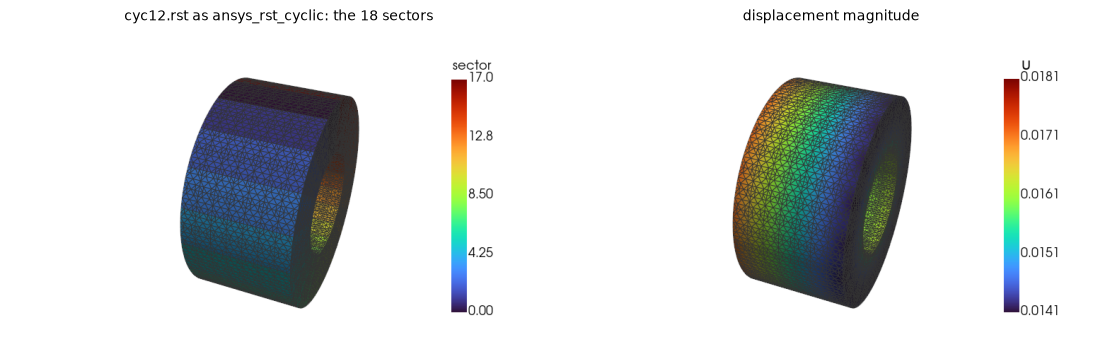

In [8]:
# cyc12.rst has FOLLW201 follower elements, which have no cell: `lenient` skips them.
sector = mp.ansys_rst.read(path('ansys/rst', 'cyc12.rst'), lenient=True)
rotor = mp.ansys_rst.read_cyclic(path('ansys/rst', 'cyc12.rst'), lenient=True)
print('sector:', len(sector.points), 'points | rotor:', len(rotor.points), 'points,',
      int(rotor.field_data['ansys:sectors'][0]), 'sectors')
grid = to_grid(rotor, point_data={'|U|': np.linalg.norm(rotor.point_data['U'], axis=1)},
               cell_data={'sector': rotor.cell_data['ansys:sector']})
gallery([(curved(grid, 2), 'sector', 'cyc12.rst as ansys_rst_cyclic: the 18 sectors', None),
         (curved(grid, 2), '|U|', 'displacement magnitude', None)], ncols=2, view=(0.4, -1.0, 0.8))